In [84]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
conn = sqlite3.connect('cs430_synth.db')
cursor = conn.cursor()

In [105]:
df = pd.read_sql_query('''
                        SELECT * FROM purchase
                        ''', conn)
df.head()

,PurchaseID,UserID,TimeDate,PaymentID,Location,Category,Subcategory
0,1,22,2025-08-06 22:53:39,1,West Willie,transportation,tolls
1,2,5,2025-04-04 22:53:39,2,Stephenmouth,food,restaurants
2,3,5,2025-03-12 22:53:39,3,North Angelamouth,miscellaneous,school supplies
3,4,8,2025-05-09 22:53:39,4,New Nicholas,transportation,maintenence
4,5,6,2025-02-16 22:53:39,5,North Jessicaburgh,food,restaurants


In [106]:
df = df.set_index('PurchaseID')

In [107]:
df.head()

,UserID,TimeDate,PaymentID,Location,Category,Subcategory
PurchaseID,,,,,,
1,22,2025-08-06 22:53:39,1,West Willie,transportation,tolls
2,5,2025-04-04 22:53:39,2,Stephenmouth,food,restaurants
3,5,2025-03-12 22:53:39,3,North Angelamouth,miscellaneous,school supplies
4,8,2025-05-09 22:53:39,4,New Nicholas,transportation,maintenence
5,6,2025-02-16 22:53:39,5,North Jessicaburgh,food,restaurants


In [108]:
df_uid = df.query('UserID == 45')

In [109]:
df_uid = df_uid.sort_values(by='TimeDate', ascending=False)

<BarContainer object of 48 artists>

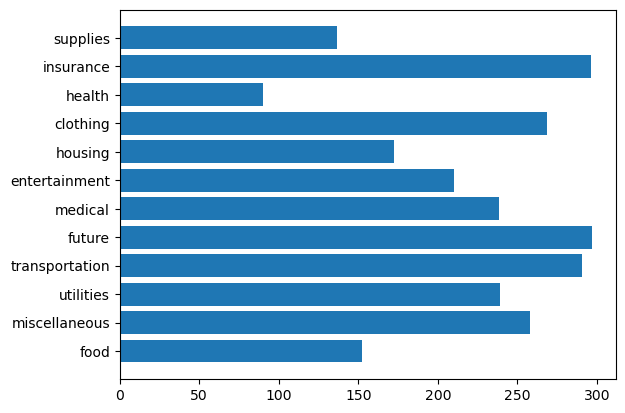

In [122]:
userid = 20

df = pd.read_sql_query(f'''
                        SELECT Users.Name, Purchase.TimeDate, Payments.Amount, Purchase.Category, Purchase.Subcategory  
                        FROM Users
                        JOIN Purchase on Users.UserID = Purchase.UserID
                        JOIN Payments on Purchase.PaymentID = Payments.PaymentID
                        WHERE Users.UserID = {userid}
                        ORDER BY Purchase.TimeDate ASC
                        ''', conn)
    
df['TimeDate'] = pd.to_datetime(df['TimeDate'])

df['TimeDate'] = df['TimeDate'].dt.floor('D')

df['running_total'] = df['Amount'].cumsum()

#df_pivot = df.pivot_table(index = df.index, columns = 'Category', values = 'Amount')
#print(df_pivot.head())

plt.barh(y = df['Category'], width = df['Amount']) 

<BarContainer object of 5 artists>

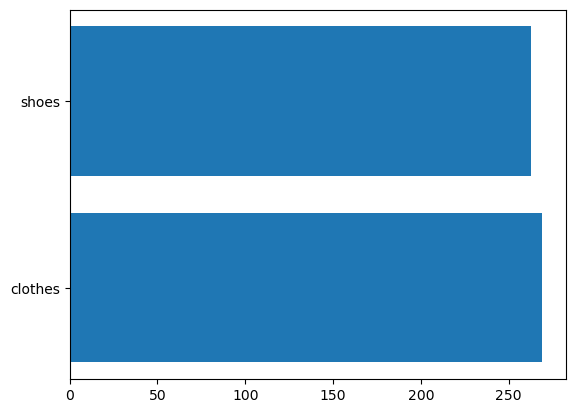

In [125]:
df_pivot = df.query("Category == 'clothing'")
plt.barh(y = df_pivot['Subcategory'], width = df_pivot['Amount']) 